In [ ]:
!pip install pandas numpy matplotlib datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Columns: ['link', 'headline', 'category', 'description', 'authors', 'date']
First 5 rows:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                         description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subd

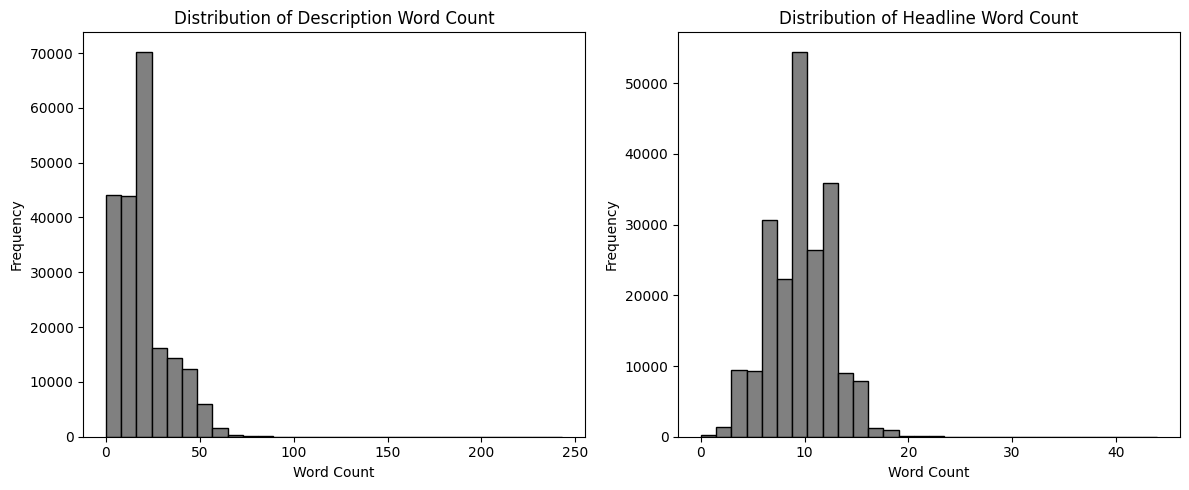

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load the dataset from the JSON file in Google Drive
dataset_path = "/content/drive/MyDrive/News_Category_Dataset_v3.json"
dataset = load_dataset("json", data_files={"train": dataset_path}, field=None)

# If the dataset uses 'short_description' instead of 'description', rename it:
if "short_description" in dataset["train"].column_names and "description" not in dataset["train"].column_names:
    dataset["train"] = dataset["train"].rename_column("short_description", "description")

# Convert the Hugging Face dataset to a Pandas DataFrame for exploration
df = pd.DataFrame(dataset["train"])

# Display the first few rows and the column names
print("Columns:", df.columns.tolist())
print("First 5 rows:")
print(df.head())

# Basic information about the dataset
print("\nDataset info:")
print(df.info())

# Compute word counts for the article description and headline
df["description_word_count"] = df["description"].apply(lambda x: len(str(x).split()))
df["headline_word_count"] = df["headline"].apply(lambda x: len(str(x).split()))

# Show descriptive statistics for word counts
print("\nDescription word count statistics:")
print(df["description_word_count"].describe())
print("\nHeadline word count statistics:")
print(df["headline_word_count"].describe())

# Plot histograms for word count distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["description_word_count"], bins=30, color='grey', edgecolor='black')
plt.title("Distribution of Description Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["headline_word_count"], bins=30, color='grey', edgecolor='black')
plt.title("Distribution of Headline Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Category distribution:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE 

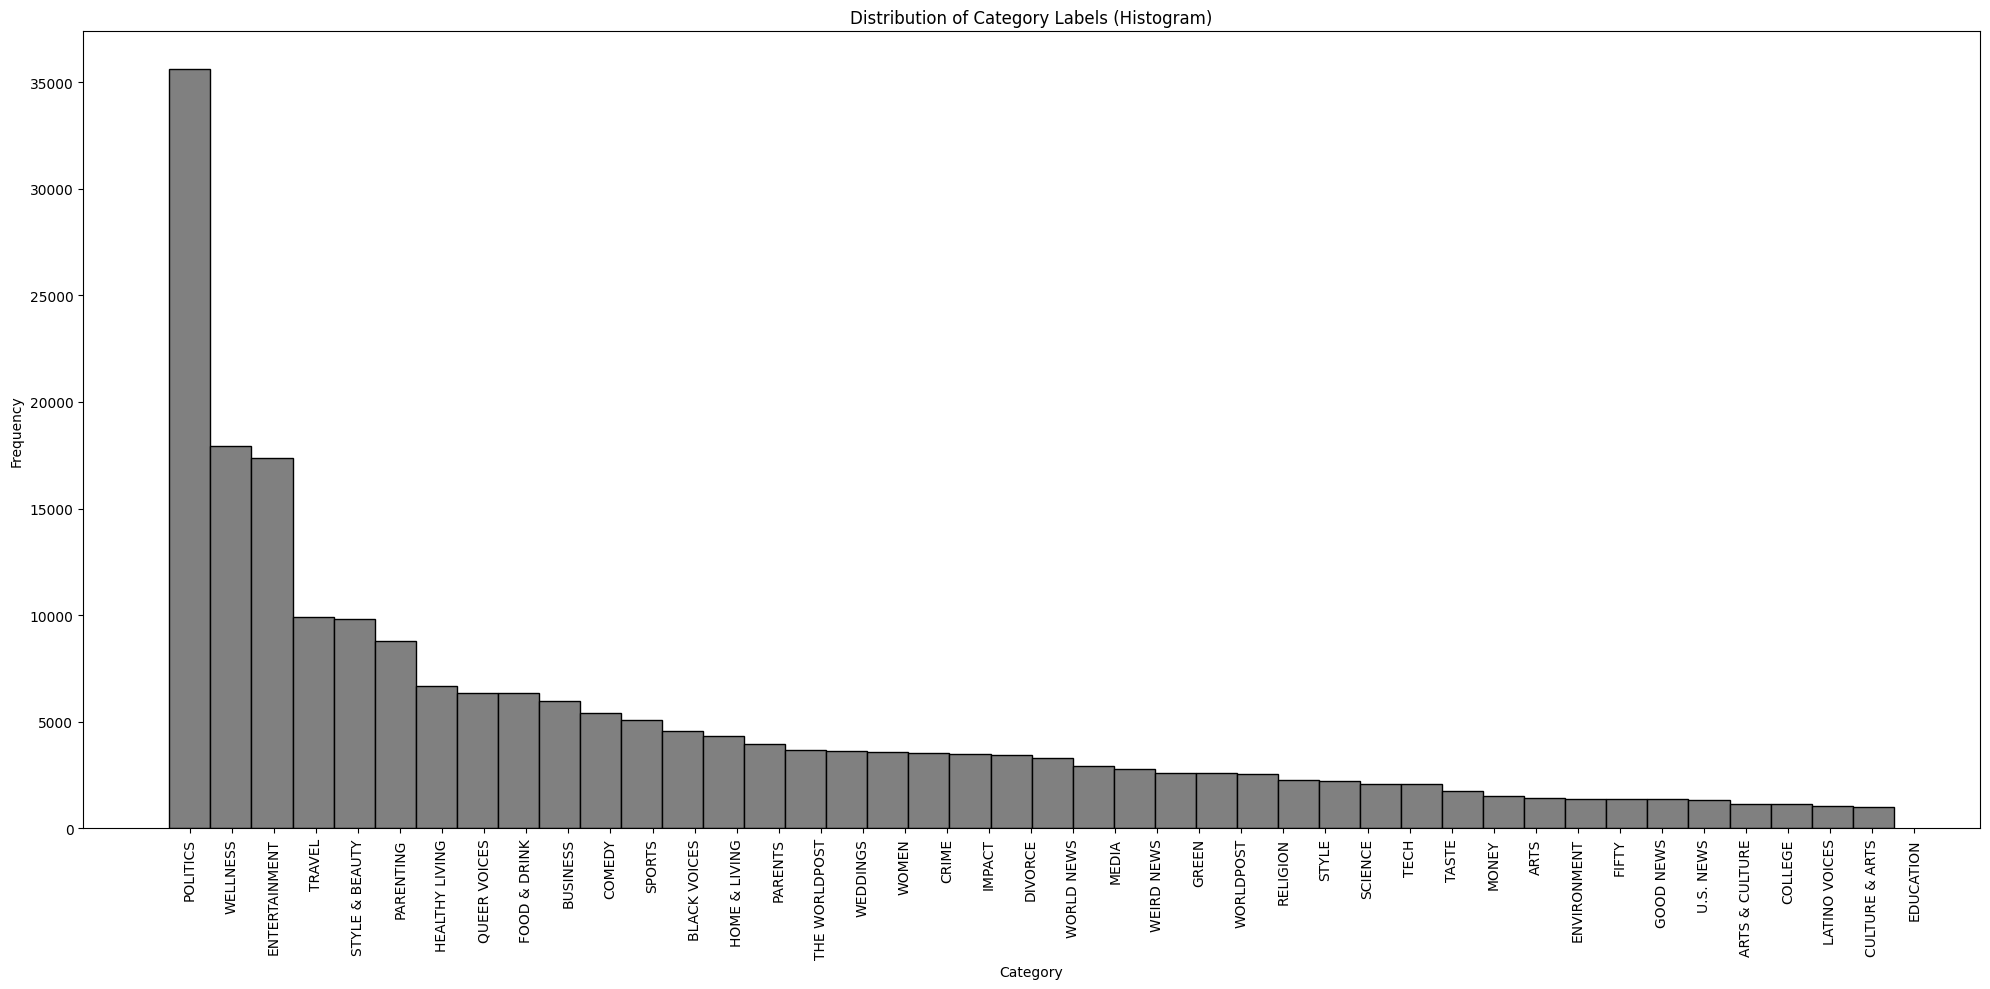

In [ ]:
# Compute the frequency of each category and sort them (value_counts returns sorted by default)
category_counts = df['category'].value_counts()
print("Category distribution:")
print(category_counts)

# Create a mapping from category to numeric index
sorted_categories = category_counts.index.tolist()
category_mapping = {cat: i for i, cat in enumerate(sorted_categories)}

# Map the category column to numeric indices using the sorted order
numeric_labels = df['category'].map(category_mapping)

# Plot histogram using numeric labels
plt.figure(figsize=(20, 10))
plt.hist(numeric_labels, bins=len(sorted_categories), color='grey', edgecolor='black', align='left')
plt.title("Distribution of Category Labels (Histogram)")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.xticks(ticks=range(len(sorted_categories)), labels=sorted_categories, rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

# Optionally, view the percentage of missing values per column
missing_percentage = df.isnull().mean() * 100
print("\nPercentage of missing values per column:")
print(missing_percentage)



Missing values per column:
link                      0
headline                  0
category                  0
description               0
authors                   0
date                      0
description_word_count    0
headline_word_count       0
dtype: int64

Percentage of missing values per column:
link                      0.0
headline                  0.0
category                  0.0
description               0.0
authors                   0.0
date                      0.0
description_word_count    0.0
headline_word_count       0.0
dtype: float64
